# Instructor Effectiveness Modeling

In [39]:
# Import Libraries
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from sklearn.model_selection import train_test_split
from sklearn.linear_model import LinearRegression
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score

# Load Dataset
df = pd.read_csv("..\Data\instructor_effectiveness_dataset.csv")


In [40]:
df.head()

,batch_id,instructor_id,course_id,completion_rate,avg_score_improvement,avg_quiz_score,dropout_rate,avg_watch_time,assignment_submission_rate,forum_activity_rate,avg_feedback_score,feedback_response_rate
0,B_1861,I_044,C_01,0.300000,14.225955,73.546528,0.647423,0.774572,0.790918,0.108414,3.766211,0.533193
1,B_0354,I_119,C_06,0.657220,22.871110,77.312331,0.425098,0.494936,0.998566,0.280550,5.000000,0.734087
2,B_1334,I_050,C_03,0.300000,16.087517,79.563687,0.700000,0.977901,0.807298,0.207013,3.517386,0.681433
3,B_0906,I_024,C_21,0.639507,24.260687,99.295316,0.334657,0.846515,0.544555,0.306395,4.207578,1.000000
4,B_1290,I_001,C_08,0.527302,31.081556,99.393425,0.521099,0.917450,0.865885,0.252289,4.426230,0.696710


In [41]:
# Remove previously created columns
df = df.drop(columns=["instructor_effectiveness", "effectiveness_tier"], errors="ignore")

In [42]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 2000 entries, 0 to 1999
Data columns (total 12 columns):
 #   Column                      Non-Null Count  Dtype  
---  ------                      --------------  -----  
 0   batch_id                    2000 non-null   object 
 1   instructor_id               2000 non-null   object 
 2   course_id                   2000 non-null   object 
 3   completion_rate             2000 non-null   float64
 4   avg_score_improvement       2000 non-null   float64
 5   avg_quiz_score              2000 non-null   float64
 6   dropout_rate                2000 non-null   float64
 7   avg_watch_time              2000 non-null   float64
 8   assignment_submission_rate  2000 non-null   float64
 9   forum_activity_rate         2000 non-null   float64
 10  avg_feedback_score          2000 non-null   float64
 11  feedback_response_rate      2000 non-null   float64
dtypes: float64(9), object(3)
memory usage: 187.6+ KB


In [43]:
# Check missing values
print(df.isnull().sum())

batch_id                      0
instructor_id                 0
course_id                     0
completion_rate               0
avg_score_improvement         0
avg_quiz_score                0
dropout_rate                  0
avg_watch_time                0
assignment_submission_rate    0
forum_activity_rate           0
avg_feedback_score            0
feedback_response_rate        0
dtype: int64


In [44]:
from sklearn.preprocessing import MinMaxScaler

scaler = MinMaxScaler()

# Normalize columns not already between 0 and 1
df[['avg_quiz_score',
    'avg_score_improvement',
    'avg_feedback_score']] = scaler.fit_transform(df[['avg_quiz_score','avg_score_improvement','avg_feedback_score']])

In [45]:
df.head()

,batch_id,instructor_id,course_id,completion_rate,avg_score_improvement,avg_quiz_score,dropout_rate,avg_watch_time,assignment_submission_rate,forum_activity_rate,avg_feedback_score,feedback_response_rate
0,B_1861,I_044,C_01,0.300000,0.238373,0.556249,0.647423,0.774572,0.790918,0.108414,0.477227,0.533193
1,B_0354,I_119,C_06,0.657220,0.493839,0.619419,0.425098,0.494936,0.998566,0.280550,1.000000,0.734087
2,B_1334,I_050,C_03,0.300000,0.293382,0.657185,0.700000,0.977901,0.807298,0.207013,0.371797,0.681433
3,B_0906,I_024,C_21,0.639507,0.534901,0.988179,0.334657,0.846515,0.544555,0.306395,0.664240,1.000000
4,B_1290,I_001,C_08,0.527302,0.736459,0.989825,0.521099,0.917450,0.865885,0.252289,0.756886,0.696710


In [46]:
# Check duplicate rows
print("Duplicate Rows:", df.duplicated().sum())

Duplicate Rows: 0


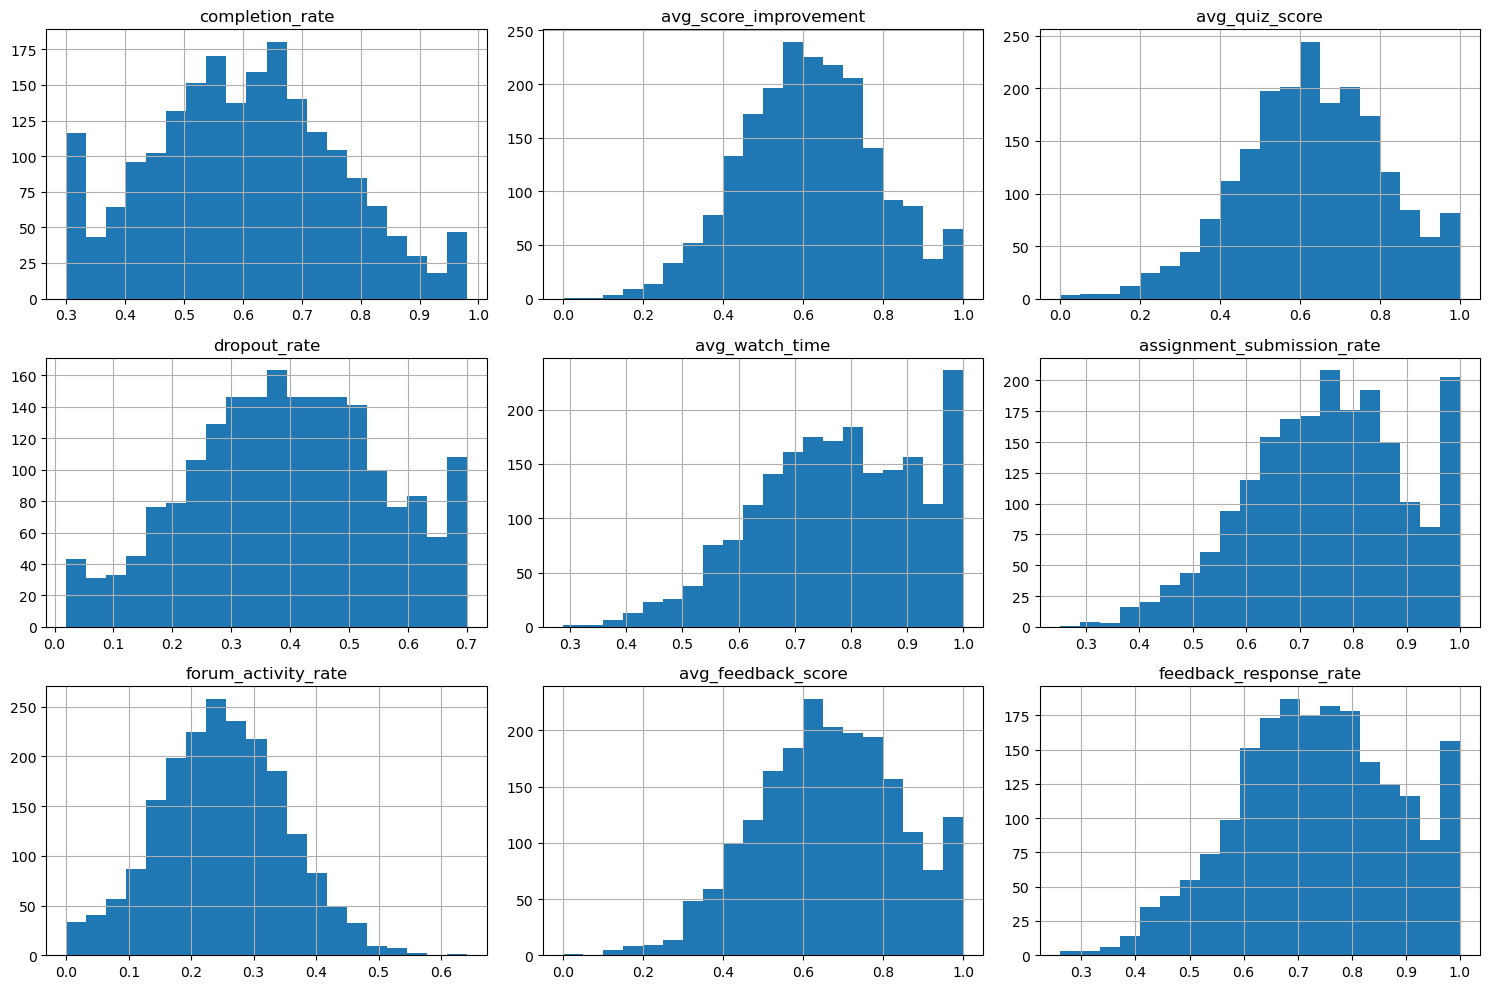

In [47]:
import matplotlib.pyplot as plt

df.hist(figsize=(15,10), bins=20)

plt.tight_layout()
plt.show()

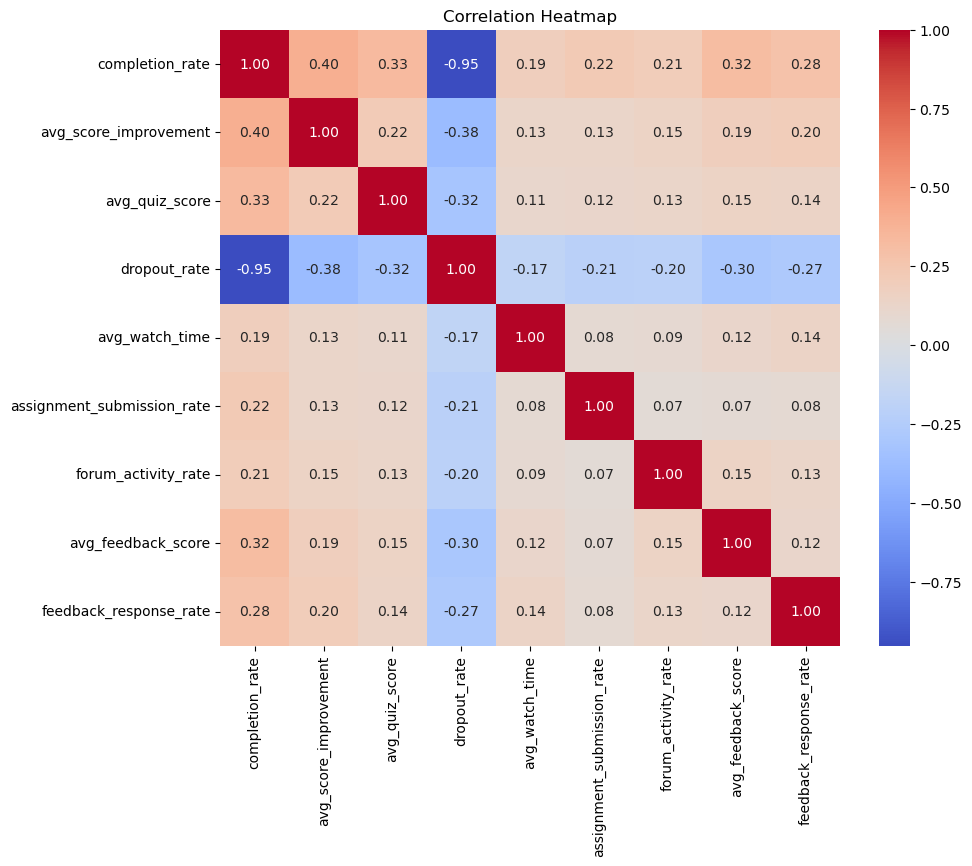

In [48]:
import seaborn as sns

plt.figure(figsize=(10,8))

sns.heatmap(
    df.corr(numeric_only=True),
    annot=True,
    cmap="coolwarm",
    fmt=".2f"
)

plt.title("Correlation Heatmap")
plt.show()

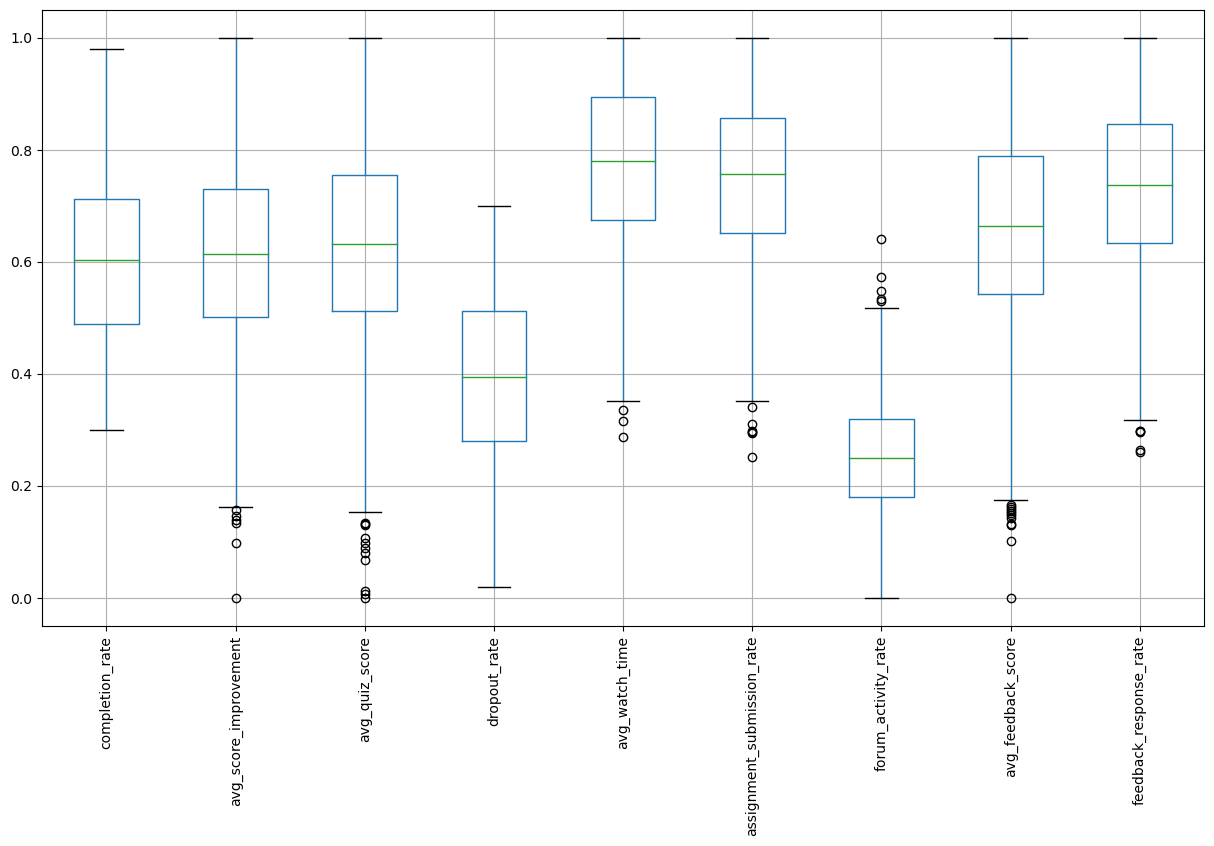

In [49]:
plt.figure(figsize=(15,8))

df.boxplot(rot=90)

plt.show()

In [50]:
print(df["instructor_id"].value_counts().describe())

count    120.000000
mean      16.666667
std        4.582270
min        7.000000
25%       13.750000
50%       17.000000
75%       19.000000
max       31.000000
Name: count, dtype: float64


# Step 2: Define Instructor Effectiveness

Since the dataset does not provide a predefined instructor effectiveness label, an Instructor Effectiveness Score is created using learner outcomes, engagement, and feedback metrics.

Higher completion rates, score improvements, engagement, and feedback indicate better instructor performance, while higher dropout rates reduce the effectiveness score.

In [51]:
# Aggregate batch-level data (df) to instructor-level data (df_instructor)
df_instructor = df.groupby('instructor_id').agg({
    'completion_rate': 'mean',
    'dropout_rate': 'mean',
    'avg_score_improvement': 'mean',
    'avg_quiz_score': 'mean',
    'avg_watch_time': 'mean',
    'assignment_submission_rate': 'mean',
    'forum_activity_rate': 'mean',
    'avg_feedback_score': 'mean',
    'feedback_response_rate': 'mean',
    'batch_id': 'count'  # Total number of batches taught by the instructor
}).rename(columns={'batch_id': 'total_batches'}).reset_index()

In [52]:
# Import MinMaxScaler
from sklearn.preprocessing import MinMaxScaler

# Create scaler object
scaler = MinMaxScaler()

# Features to normalize
cols_to_scale = [
    "avg_score_improvement",
    "avg_quiz_score",
    "avg_feedback_score"
]

# Scale selected features
df_instructor[cols_to_scale] = scaler.fit_transform(df_instructor[cols_to_scale])

In [53]:
# Calculate instructor effectiveness score
df_instructor["instructor_effectiveness"] = (
      0.25 * df_instructor["completion_rate"]
    - 0.20 * df_instructor["dropout_rate"]
    + 0.20 * df_instructor["avg_score_improvement"]
    + 0.15 * df_instructor["avg_quiz_score"]
    + 0.10 * df_instructor["avg_watch_time"]
    + 0.10 * df_instructor["assignment_submission_rate"]
    + 0.05 * df_instructor["forum_activity_rate"]
    + 0.10 * df_instructor["avg_feedback_score"]
    + 0.05 * df_instructor["feedback_response_rate"]
)

Weights are assigned based on the expected contribution of each metric.

• Completion rate receives the highest weight because it directly reflects learner success.
• Dropout rate has a negative weight since higher dropout indicates lower effectiveness.
• Score improvement measures learning gains.
• Engagement and feedback metrics contribute positively to the final score.

In [54]:
# Display score statistics
df_instructor["instructor_effectiveness"].describe()

count    120.000000
mean       0.508852
std        0.149604
min        0.125676
25%        0.417827
50%        0.511648
75%        0.589550
max        0.895063
Name: instructor_effectiveness, dtype: float64

In [55]:
# Calculate tier thresholds
q1 = df_instructor["instructor_effectiveness"].quantile(0.33)
q2 = df_instructor["instructor_effectiveness"].quantile(0.66)

print("33rd Percentile:", q1)
print("66th Percentile:", q2)

33rd Percentile: 0.4496984949234913
66th Percentile: 0.5616795413078968


The 33rd and 66th percentiles are used to divide instructors into Low, Medium, and High effectiveness groups. This creates balanced classes for model training.

In [56]:
# Assign effectiveness tiers
def assign_tier(score):
    if score <= q1:
        return "Low"
    elif score <= q2:
        return "Medium"
    else:
        return "High"

df_instructor["effectiveness_tier"] = df_instructor["instructor_effectiveness"].apply(assign_tier)

In [57]:
# Count instructors in each tier
print(df_instructor["effectiveness_tier"].value_counts())

effectiveness_tier
High      41
Low       40
Medium    39
Name: count, dtype: int64


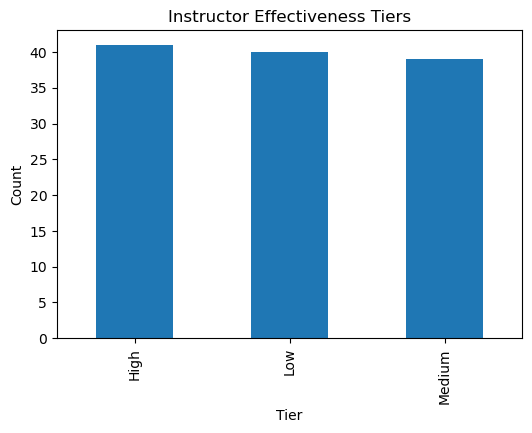

In [58]:
# Plot tier distribution
import matplotlib.pyplot as plt

df_instructor["effectiveness_tier"].value_counts().plot(
    kind="bar",
    figsize=(6,4)
)

plt.title("Instructor Effectiveness Tiers")
plt.xlabel("Tier")
plt.ylabel("Count")
plt.show()

# Select Features and Target

In [59]:
# Select input features
X = df_instructor[
    [
        "completion_rate",
        "dropout_rate",
        "avg_score_improvement",
        "avg_quiz_score",
        "avg_watch_time",
        "assignment_submission_rate",
        "forum_activity_rate",
        "avg_feedback_score",
        "feedback_response_rate",
        "total_batches"
    ]
]

# Select target variable
y = df_instructor["effectiveness_tier"]

In [60]:
# Import train-test split
from sklearn.model_selection import train_test_split

# Split into training and testing sets
X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.20,
    random_state=42,
    stratify=y
)

80% of the data is used for training and 20% for testing. Stratified sampling preserves the class distribution in both sets.

In [61]:
# Display dataset sizes
print("X_train :", X_train.shape)
print("X_test  :", X_test.shape)
print("y_train :", y_train.shape)
print("y_test  :", y_test.shape)

X_train : (96, 10)
X_test  : (24, 10)
y_train : (96,)
y_test  : (24,)


# Model Training

In [62]:
# Import Logistic Regression
from sklearn.linear_model import LogisticRegression

# Create model
lr = LogisticRegression(max_iter=1000)

# Train model
lr.fit(X_train, y_train)

# Predict test data
y_pred_lr = lr.predict(X_test)

In [63]:
# Import Decision Tree
from sklearn.tree import DecisionTreeClassifier

# Create model
dt = DecisionTreeClassifier(random_state=42)

# Train model
dt.fit(X_train, y_train)

# Predict test data
y_pred_dt = dt.predict(X_test)

In [64]:
# Import Random Forest
from sklearn.ensemble import RandomForestClassifier

# Create model
rf = RandomForestClassifier(
    n_estimators=100,
    random_state=42
)

# Train model
rf.fit(X_train, y_train)

# Predict test data
y_pred_rf = rf.predict(X_test)

In [65]:
# Import StandardScaler
from sklearn.preprocessing import StandardScaler

# Create scaler
scaler = StandardScaler()

# Scale training data
X_train_scaled = scaler.fit_transform(X_train)

# Scale testing data
X_test_scaled = scaler.transform(X_test)

Feature Scaling
KNN and SVM are distance-based algorithms. StandardScaler is used to standardize the features before training these models.

In [66]:
# Import KNN
from sklearn.neighbors import KNeighborsClassifier

# Create model
knn = KNeighborsClassifier(n_neighbors=5)

# Train model
knn.fit(X_train_scaled, y_train)

# Predict test data
y_pred_knn = knn.predict(X_test_scaled)

In [67]:
# Import SVM
from sklearn.svm import SVC

# Create model
svm = SVC(random_state=42)

# Train model
svm.fit(X_train_scaled, y_train)

# Predict test data
y_pred_svm = svm.predict(X_test_scaled)

In [68]:
# Import Gaussian Naive Bayes
from sklearn.naive_bayes import GaussianNB

# Create model
nb = GaussianNB()

# Train model
nb.fit(X_train, y_train)

# Predict test data
y_pred_nb = nb.predict(X_test)

All six classification models have been trained using the instructor-level dataset. Their performance will now be evaluated and compared using Accuracy, Precision, Recall, F1-score, and Confusion Matrix to identify the most suitable model.

# Model Evaluation

In [69]:
# Import evaluation metrics
from sklearn.metrics import (
    accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    confusion_matrix,
    classification_report
)

In [70]:
# Store predictions
models = {
    "Logistic Regression": y_pred_lr,
    "Decision Tree": y_pred_dt,
    "Random Forest": y_pred_rf,
    "KNN": y_pred_knn,
    "SVM": y_pred_svm,
    "Naive Bayes": y_pred_nb
}

# Empty list for results
results = []

# Evaluate each model
for name, pred in models.items():

    accuracy = accuracy_score(y_test, pred)
    precision = precision_score(y_test, pred, average="weighted")
    recall = recall_score(y_test, pred, average="weighted")
    f1 = f1_score(y_test, pred, average="weighted")

    results.append([name, accuracy, precision, recall, f1])

    print("="*50)
    print(name)
    print("="*50)

    print("Accuracy :", accuracy)
    print("Precision:", precision)
    print("Recall   :", recall)
    print("F1 Score :", f1)

    print("\nClassification Report")
    print(classification_report(y_test, pred))

    print("\nConfusion Matrix")
    print(confusion_matrix(y_test, pred))
    print("\n")

Logistic Regression
Accuracy : 0.9166666666666666
Precision: 0.9259259259259259
Recall   : 0.9166666666666666
F1 Score : 0.9131652661064426

Classification Report
              precision    recall  f1-score   support

        High       0.89      1.00      0.94         8
         Low       0.89      1.00      0.94         8
      Medium       1.00      0.75      0.86         8

    accuracy                           0.92        24
   macro avg       0.93      0.92      0.91        24
weighted avg       0.93      0.92      0.91        24


Confusion Matrix
[[8 0 0]
 [0 8 0]
 [1 1 6]]


Decision Tree
Accuracy : 0.9166666666666666
Precision: 0.9333333333333332
Recall   : 0.9166666666666666
F1 Score : 0.9153439153439153

Classification Report
              precision    recall  f1-score   support

        High       1.00      0.75      0.86         8
         Low       1.00      1.00      1.00         8
      Medium       0.80      1.00      0.89         8

    accuracy                     

In [71]:
# Create comparison dataframe
import pandas as pd

results_df = pd.DataFrame(
    results,
    columns=[
        "Model",
        "Accuracy",
        "Precision",
        "Recall",
        "F1 Score"
    ]
)

# Sort by accuracy
results_df = results_df.sort_values(
    by="Accuracy",
    ascending=False
)

results_df

,Model,Accuracy,Precision,Recall,F1 Score
2,Random Forest,0.958333,0.962963,0.958333,0.958170
0,Logistic Regression,0.916667,0.925926,0.916667,0.913165
1,Decision Tree,0.916667,0.933333,0.916667,0.915344
3,KNN,0.833333,0.832011,0.833333,0.830392
4,SVM,0.833333,0.832011,0.833333,0.830392
5,Naive Bayes,0.791667,0.837121,0.791667,0.793691


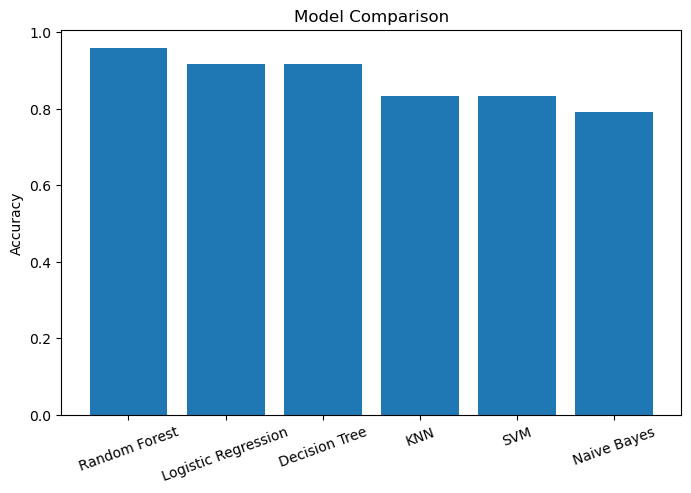

In [72]:
# Plot model accuracy
import matplotlib.pyplot as plt

plt.figure(figsize=(8,5))

plt.bar(results_df["Model"], results_df["Accuracy"])

plt.xticks(rotation=20)

plt.ylabel("Accuracy")

plt.title("Model Comparison")

plt.show()

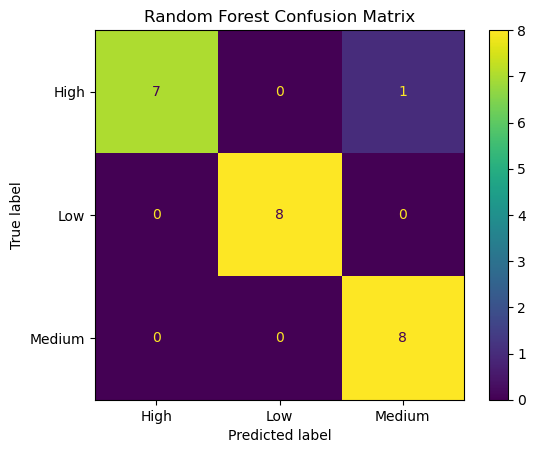

In [73]:
# Display confusion matrix for best model
from sklearn.metrics import ConfusionMatrixDisplay

ConfusionMatrixDisplay.from_predictions(
    y_test,
    y_pred_rf
)

plt.title("Random Forest Confusion Matrix")

plt.show()

In [74]:
# Display class distribution
print(df_instructor["effectiveness_tier"].value_counts())

effectiveness_tier
High      41
Low       40
Medium    39
Name: count, dtype: int64


The instructor effectiveness tiers are reasonably balanced. Therefore, accuracy is an appropriate evaluation metric, while Precision, Recall, and F1-score provide additional insight into model performance.

In [75]:
import joblib

# Save the trained Random Forest model to a file
joblib.dump(rf, "random_forest_model.pkl")

['random_forest_model.pkl']

In [76]:

joblib.dump(scaler, "scaler.pkl")

['scaler.pkl']

The project begins with a comprehensive Exploratory Data Analysis (EDA) on the raw dataset of 2,000 course batch records to evaluate distributions, detect missing values or duplicate records, and inspect feature correlations. Because instructors teach across multiple batches, the batch-level dataset is aggregated to the instructor level, transforming the data into 120 unique instructor profiles while generating engineered features such as total batches taught. To quantify teaching quality, a custom composite Instructor Effectiveness Score is defined using a domain-weighted formula that rewards positive learner outcomes—such as course completion, score improvements, quiz scores, assignment submissions, video watch time, and feedback scores—while penalizing negative indicators like dropout rates. This continuous score is then categorized into three balanced performance tiers (High, Medium, Low) using 33rd and 66th percentile thresholds to ensure uniform class distribution. The dataset is partitioned into an 80/20 stratified train-test split to preserve class proportions, followed by scaling distance-sensitive models on the training set to prevent data leakage. Six supervised classification algorithms—Logistic Regression, Decision Tree, Random Forest, K-Nearest Neighbors, Support Vector Machine, and Naive Bayes—are trained and benchmarked. Among these, the Random Forest model achieves the top performance with a 95.8% F1-score. Finally, feature importance analysis reveals that completion rates, score improvements, and dropout rates are the strongest predictors of instructor success, providing actionable insights for EdTech diagnostic tools and peer coaching programs.